# Introduction

In this notebook, we will do a comprehensive analysis of the Android app market by comparing thousands of apps in the Google Play store.

# About the Dataset of Google Play Store Apps & Reviews

**Data Source:** <br>
App and review data was scraped from the Google Play Store by Lavanya Gupta in 2018. Original files listed [here](
https://www.kaggle.com/lava18/google-play-store-apps).

# Import Statements

In [93]:
import pandas as pd
import plotly.express as px

# Notebook Presentation

In [96]:
# Show numeric output in decimal format e.g., 2.15
pd.options.display.float_format = '{:,.2f}'.format

# Read the Dataset

In [99]:
df_apps = pd.read_csv('apps.csv')

# Data Cleaning

**Challenge**: How many rows and columns does `df_apps` have? What are the column names? Look at a random sample of 5 different rows with [.sample()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html).

In [103]:
df_apps.shape

(10841, 12)

In [105]:
df_apps.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size_MBs', 'Installs', 'Type',
       'Price', 'Content_Rating', 'Genres', 'Last_Updated', 'Android_Ver'],
      dtype='object')

In [107]:
df_apps.sample(3)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres,Last_Updated,Android_Ver
3422,DZ Mobile Market,SHOPPING,NaN,59,6.00,"10,000",Free,0,Everyone,Shopping,"February 1, 2018",4.0.3 and up
3322,DG UPnP Player Free,VIDEO_PLAYERS,3.20,39,12.00,"10,000",Free,0,Everyone,Video Players & Editors,"March 18, 2016",4.0.3 and up
10805,Facebook,SOCIAL,4.10,78158306,5.30,"1,000,000,000",Free,0,Teen,Social,"August 3, 2018",Varies with device


### Drop Unused Columns

**Challenge**: Remove the columns called `Last_Updated` and `Android_Version` from the DataFrame. We will not use these columns. 

In [110]:
df_apps.drop(['Last_Updated','Android_Ver'], axis=1, inplace=True)
df_apps.shape

(10841, 10)

### Find and Remove NaN values in Ratings

**Challenge**: How may rows have a NaN value (not-a-number) in the Ratings column? Create DataFrame called `df_apps_clean` that does not include these rows. 

In [113]:
df_apps.isna()
df_apps.head()

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
0,Ak Parti Yardım Toplama,SOCIAL,NaN,0,8.70,0,Paid,$13.99,Teen,Social
1,Ain Arabic Kids Alif Ba ta,FAMILY,NaN,0,33.00,0,Paid,$2.99,Everyone,Education
2,Popsicle Launcher for Android P 9.0 launcher,PERSONALIZATION,NaN,0,5.50,0,Paid,$1.49,Everyone,Personalization
3,Command & Conquer: Rivals,FAMILY,NaN,0,19.00,0,NaN,0,Everyone 10+,Strategy
4,CX Network,BUSINESS,NaN,0,10.00,0,Free,0,Everyone,Business


In [115]:
df_clean_apps = df_apps.dropna() 
df_clean_apps.shape

(9367, 10)

### Find and Remove Duplicates

**Challenge**: Are there any duplicates in data? Check for duplicates using the [.duplicated()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.duplicated.html) function. How many entries can you find for the "Instagram" app? Use [.drop_duplicates()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop_duplicates.html) to remove any duplicates from `df_apps_clean`. 


In [118]:
duplicated_rows = df_clean_apps[df_clean_apps.duplicated(subset=['App','Type','Price'])] # kiske base pe hume dupllicates dekhne hai
# ye hum subset mein define kr dete hai aur agar poori table mein hi dekhna hota hai to subset ka use nhi krte hai 
print(duplicated_rows.shape)
duplicated_rows.head()

(1168, 10)


,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
946,420 BZ Budeze Delivery,MEDICAL,5.00,2,11.00,100,Free,0,Mature 17+,Medical
1133,MouseMingle,DATING,2.70,3,3.90,100,Free,0,Mature 17+,Dating
1196,"Cardiac diagnosis (heart rate, arrhythmia)",MEDICAL,4.40,8,6.50,100,Paid,$12.99,Everyone,Medical
1231,Sway Medical,MEDICAL,5.00,3,22.00,100,Free,0,Everyone,Medical
1247,Chat Kids - Chat Room For Kids,DATING,4.70,6,4.90,100,Free,0,Mature 17+,Dating


In [120]:

df_clean_apps.drop_duplicates(subset=['App','Type','Price'] , inplace=True)

/var/folders/67/_6_dylh17cb7vcnr8wlnl7q80000gn/T/ipykernel_33167/1809132921.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [122]:
df_clean_apps.shape

(8199, 10)

# Find Highest Rated Apps

**Challenge**: Identify which apps are the highest rated. What problem might you encounter if you rely exclusively on ratings alone to determine the quality of an app?

In [125]:
df_clean_apps.sort_values('Rating', ascending=False).head()

# isse hume ye pata chal rha hai jin apps pe kam reviews aur downloads hai keval unhi rating 5.0 hai 

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
21,KBA-EZ Health Guide,MEDICAL,5.00,4,25.00,1,Free,0,Everyone,Medical
1230,Sway Medical,MEDICAL,5.00,3,22.00,100,Free,0,Everyone,Medical
1227,AJ Men's Grooming,LIFESTYLE,5.00,2,22.00,100,Free,0,Everyone,Lifestyle
1224,FK Dedinje BGD,SPORTS,5.00,36,2.60,100,Free,0,Everyone,Sports
1223,CB VIDEO VISION,PHOTOGRAPHY,5.00,13,2.60,100,Free,0,Everyone,Photography


# Find 5 Largest Apps in terms of Size (MBs)

**Challenge**: What's the size in megabytes (MB) of the largest Android apps in the Google Play Store. Based on the data, do you think there could be limit in place or can developers make apps as large as they please? 

In [128]:
df_clean_apps.sort_values('Size_MBs', ascending=False).head(5) 

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
9942,Talking Babsy Baby: Baby Games,LIFESTYLE,4.00,140995,100.00,"10,000,000",Free,0,Everyone,Lifestyle;Pretend Play
10687,Hungry Shark Evolution,GAME,4.50,6074334,100.00,"100,000,000",Free,0,Teen,Arcade
9943,Miami crime simulator,GAME,4.00,254518,100.00,"10,000,000",Free,0,Mature 17+,Action
9944,Gangster Town: Vice District,FAMILY,4.30,65146,100.00,"10,000,000",Free,0,Mature 17+,Simulation
3144,Vi Trainer,HEALTH_AND_FITNESS,3.60,124,100.00,"5,000",Free,0,Everyone,Health & Fitness


# Find the 5 App with Most Reviews

**Challenge**: Which apps have the highest number of reviews? Are there any paid apps among the top 50?

In [131]:
df_clean_apps.sort_values('Reviews', ascending=False).head(5)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
10805,Facebook,SOCIAL,4.10,78158306,5.30,"1,000,000,000",Free,0,Teen,Social
10785,WhatsApp Messenger,COMMUNICATION,4.40,69119316,3.50,"1,000,000,000",Free,0,Everyone,Communication
10806,Instagram,SOCIAL,4.50,66577313,5.30,"1,000,000,000",Free,0,Teen,Social
10784,Messenger – Text and Video Chat for Free,COMMUNICATION,4.00,56642847,3.50,"1,000,000,000",Free,0,Everyone,Communication
10650,Clash of Clans,GAME,4.60,44891723,98.00,"100,000,000",Free,0,Everyone 10+,Strategy


# Plotly Pie and Donut Charts - Visualise Categorical Data: Content Ratings

In [134]:
content_rating_counts = df_clean_apps.Content_Rating.value_counts()
content_rating_counts

Content_Rating
Everyone           6621
Teen                912
Mature 17+          357
Everyone 10+        305
Adults only 18+       3
Unrated               1
Name: count, dtype: int64

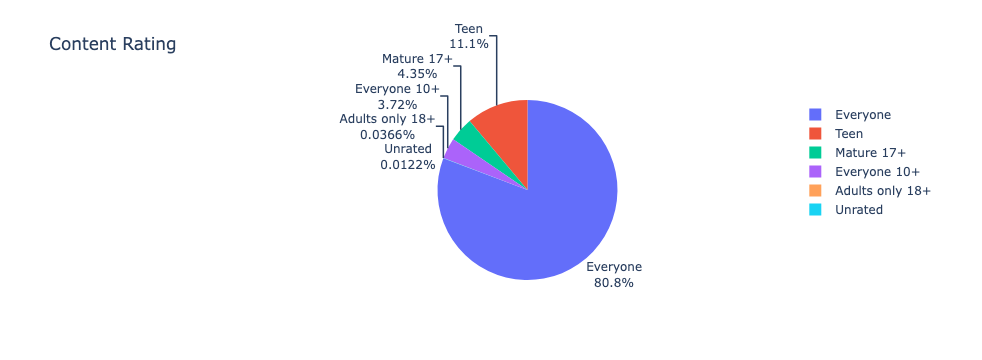

In [136]:
pie_chart = px.pie(labels=content_rating_counts.index, values=content_rating_counts.values, title='Content Rating', names=content_rating_counts.index)
pie_chart.update_traces(textposition='outside', textinfo='percent+label')
pie_chart.show()

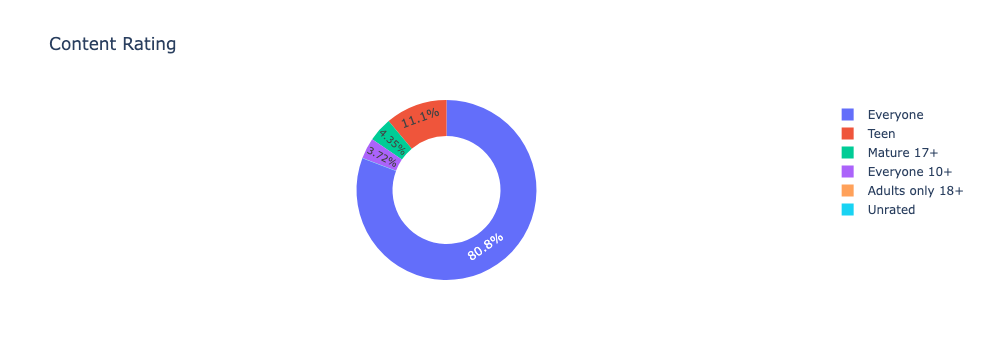

In [138]:
# donut chart banane ke liye hume keval ek aur argument dena hota hai pie mein i.e hole=
pie_chart = px.pie(labels=content_rating_counts.index, values=content_rating_counts.values, title='Content Rating', names=content_rating_counts.index, hole=0.6)
pie_chart.update_traces(textposition='inside', textinfo='percent')
pie_chart.show()

# Numeric Type Conversion: Examine the Number of Installs

**Challenge**: How many apps had over 1 billion (that's right - BILLION) installations? How many apps just had a single install? 

Check the datatype of the Installs column.

Count the number of apps at each level of installations. 

Convert the number of installations (the Installs column) to a numeric data type. Hint: this is a 2-step process. You'll have make sure you remove non-numeric characters first. 

In [141]:
print(df_clean_apps.Installs.describe()) 
# OR 
print(df_clean_apps.info()) 

count          8199
unique           19
top       1,000,000
freq           1417
Name: Installs, dtype: object
<class 'pandas.core.frame.DataFrame'>
Index: 8199 entries, 21 to 10835
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8199 non-null   object 
 1   Category        8199 non-null   object 
 2   Rating          8199 non-null   float64
 3   Reviews         8199 non-null   int64  
 4   Size_MBs        8199 non-null   float64
 5   Installs        8199 non-null   object 
 6   Type            8199 non-null   object 
 7   Price           8199 non-null   object 
 8   Content_Rating  8199 non-null   object 
 9   Genres          8199 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 704.6+ KB
None


In [143]:
df_clean_apps[['App', 'Installs']].groupby('Installs').count() 

,App
Installs,
1,3
"1,000",698
"1,000,000",1417
"1,000,000,000",20
10,69
"10,000",988
"10,000,000",933
100,303
"100,000",1096


In [145]:
# Humara jo installs wala column hai uska data type object detect kr rha hai because of the commas 
# so sbse pehle hum unn commas ko hatayenge fir hum unhe numbers mein convert karenge 

df_clean_apps.Installs = df_clean_apps.Installs.astype(str).str.replace(',', "") 
df_clean_apps.Installs = pd.to_numeric(df_clean_apps.Installs) 
df_clean_apps[['App', 'Installs']].groupby('Installs').count() 

/var/folders/67/_6_dylh17cb7vcnr8wlnl7q80000gn/T/ipykernel_33167/3740551304.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/67/_6_dylh17cb7vcnr8wlnl7q80000gn/T/ipykernel_33167/3740551304.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,App
Installs,
1,3
5,9
10,69
50,56
100,303
500,199
1000,698
5000,425
10000,988


# Find the Most Expensive Apps, Filter out the Junk, and Calculate a (ballpark) Sales Revenue Estimate

Let's examine the Price column more closely.

**Challenge**: Convert the price column to numeric data. Then investigate the top 20 most expensive apps in the dataset.

Remove all apps that cost more than $250 from the `df_apps_clean` DataFrame.

Add a column called 'Revenue_Estimate' to the DataFrame. This column should hold the price of the app times the number of installs. What are the top 10 highest grossing paid apps according to this estimate? Out of the top 10 highest grossing paid apps, how many are games?


In [148]:
print(df_clean_apps.Price.describe())

print(df_clean_apps.sort_values('Price', ascending=False).head(20)) 

count     8199
unique      73
top          0
freq      7595
Name: Price, dtype: object
                                                    App            Category  \
21                                  KBA-EZ Health Guide             MEDICAL   
7182                             Pushbullet - SMS on PC        PRODUCTIVITY   
7196                       Al Quran Audio (Full 30 Juz)              FAMILY   
7195                                  Funny Quotes Free       ENTERTAINMENT   
7194                      EX File Explorer File Manager        PRODUCTIVITY   
7193                                      Zooper Widget     PERSONALIZATION   
7192                      Ultimate Clash Royale Tracker              FAMILY   
7191                                                 ao              FAMILY   
7189                       FastMeet: Chat, Dating, Love              DATING   
7188      issuu - Read Magazines, Catalogs, Newspapers.  NEWS_AND_MAGAZINES   
7187       OO Launcher for Android O 8.0 Ore

In [150]:
# Price column ke data type ko object se convert krke numbers mein kr rhe hai 

df_clean_apps.Price = df_clean_apps.Price.astype(str).str.replace('$',"") 
df_clean_apps.Price = pd.to_numeric(df_clean_apps.Price) 
df_clean_apps.Price.describe() 

/var/folders/67/_6_dylh17cb7vcnr8wlnl7q80000gn/T/ipykernel_33167/1904218669.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/67/_6_dylh17cb7vcnr8wlnl7q80000gn/T/ipykernel_33167/1904218669.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



count   8,199.00
mean        1.04
std        16.85
min         0.00
25%         0.00
50%         0.00
75%         0.00
max       400.00
Name: Price, dtype: float64

### The most expensive apps sub $250

In [153]:
rows_to_remove = df_clean_apps[df_clean_apps['Price']>250].index 

In [155]:
df_clean_apps.drop(rows_to_remove, inplace=True) 

/var/folders/67/_6_dylh17cb7vcnr8wlnl7q80000gn/T/ipykernel_33167/345336620.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [157]:
df_clean_apps[df_clean_apps['Price']>250].count() 

App               0
Category          0
Rating            0
Reviews           0
Size_MBs          0
Installs          0
Type              0
Price             0
Content_Rating    0
Genres            0
dtype: int64

### Highest Grossing Paid Apps (ballpark estimate)

In [160]:
df_clean_apps['Revenue_Estimate'] = df_clean_apps.Price.mul(df_clean_apps.Installs) 

/var/folders/67/_6_dylh17cb7vcnr8wlnl7q80000gn/T/ipykernel_33167/1949449483.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [162]:
df_clean_apps.sort_values('Revenue_Estimate', ascending=False).head(10) 

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres,Revenue_Estimate
9220,Minecraft,FAMILY,4.50,2376564,19.00,10000000,Paid,6.99,Everyone 10+,Arcade;Action & Adventure,"69,900,000.00"
8825,Hitman Sniper,GAME,4.60,408292,29.00,10000000,Paid,0.99,Mature 17+,Action,"9,900,000.00"
7151,Grand Theft Auto: San Andreas,GAME,4.40,348962,26.00,1000000,Paid,6.99,Mature 17+,Action,"6,990,000.00"
7477,Facetune - For Free,PHOTOGRAPHY,4.40,49553,48.00,1000000,Paid,5.99,Everyone,Photography,"5,990,000.00"
7977,Sleep as Android Unlock,LIFESTYLE,4.50,23966,0.85,1000000,Paid,5.99,Everyone,Lifestyle,"5,990,000.00"
6594,DraStic DS Emulator,GAME,4.60,87766,12.00,1000000,Paid,4.99,Everyone,Action,"4,990,000.00"
6082,Weather Live,WEATHER,4.50,76593,4.75,500000,Paid,5.99,Everyone,Weather,"2,995,000.00"
7954,Bloons TD 5,FAMILY,4.60,190086,94.00,1000000,Paid,2.99,Everyone,Strategy,"2,990,000.00"
7633,Five Nights at Freddy's,GAME,4.60,100805,50.00,1000000,Paid,2.99,Teen,Action,"2,990,000.00"
6746,Card Wars - Adventure Time,FAMILY,4.30,129603,23.00,1000000,Paid,2.99,Everyone 10+,Card;Action & Adventure,"2,990,000.00"


# Plotly Bar Charts & Scatter Plots: Analysing App Categories

In [165]:
df_clean_apps.Category.nunique() 

33

In [169]:
top_10_category = df_clean_apps.Category.value_counts()[:10] 
top_10_category

Category
FAMILY             1606
GAME                910
TOOLS               719
PRODUCTIVITY        301
PERSONALIZATION     298
LIFESTYLE           297
FINANCE             296
MEDICAL             292
PHOTOGRAPHY         263
BUSINESS            262
Name: count, dtype: int64

### Vertical Bar Chart - Highest Competition (Number of Apps)

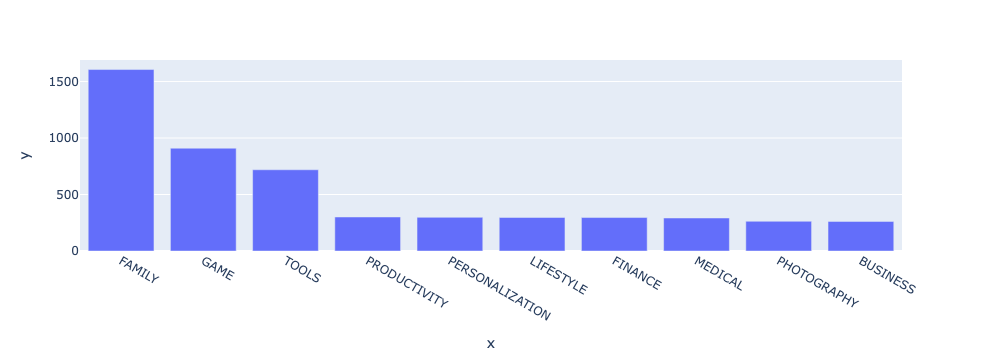

In [175]:
bar_chart = px.bar(x=top_10_category.index, y=top_10_category.values) 
bar_chart.show() 

### Horizontal Bar Chart - Most Popular Categories (Highest Downloads)

In [201]:
category_installs = df_clean_apps.groupby('Category').agg({'Installs':pd.Series.sum})
category_installs.sort_values('Installs', ascending=True, inplace=True)   

In [203]:
category_installs.head() 

,Installs
Category,
EVENTS,15949410
BEAUTY,26916200
PARENTING,31116110
MEDICAL,39162676
COMICS,44931100


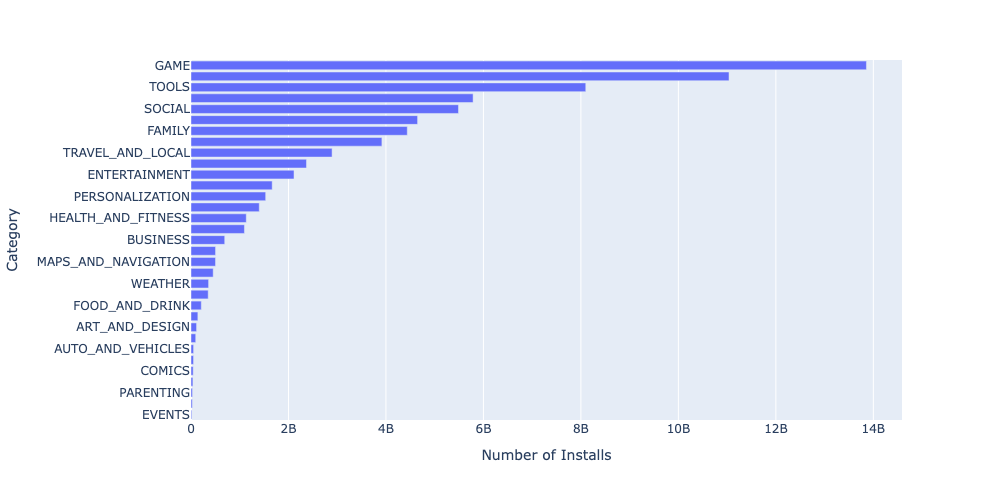

In [236]:
horizontal_bar_chart = px.bar(x=category_installs.Installs, y=category_installs.index, orientation='h') 
horizontal_bar_chart.update_layout(xaxis_title='Number of Installs', 
                                   yaxis_title='Category', 
                                   height=500) 
horizontal_bar_chart.show() 

### Category Concentration - Downloads vs. Competition

**Challenge**: 
* First, create a DataFrame that has the number of apps in one column and the number of installs in another:

<img src=https://imgur.com/uQRSlXi.png width="350">

* Then use the [plotly express examples from the documentation](https://plotly.com/python/line-and-scatter/) alongside the [.scatter() API reference](https://plotly.com/python-api-reference/generated/plotly.express.scatter.html)to create scatter plot that looks like this. 

<img src=https://imgur.com/cHsqh6a.png>

*Hint*: Use the size, hover_name and color parameters in .scatter(). To scale the yaxis, call .update_layout() and specify that the yaxis should be on a log-scale like so: yaxis=dict(type='log') 

In [215]:
cat_number = df_clean_apps.groupby('Category').agg({'App': pd.Series.count}) 

In [217]:
cat_merged_df = pd.merge(cat_number, category_installs, on='Category', how='inner') 

In [219]:
cat_merged_df.head() 

,App,Installs
Category,,
ART_AND_DESIGN,61,114233100
AUTO_AND_VEHICLES,73,53129800
BEAUTY,42,26916200
BOOKS_AND_REFERENCE,169,1665791655
BUSINESS,262,692018120


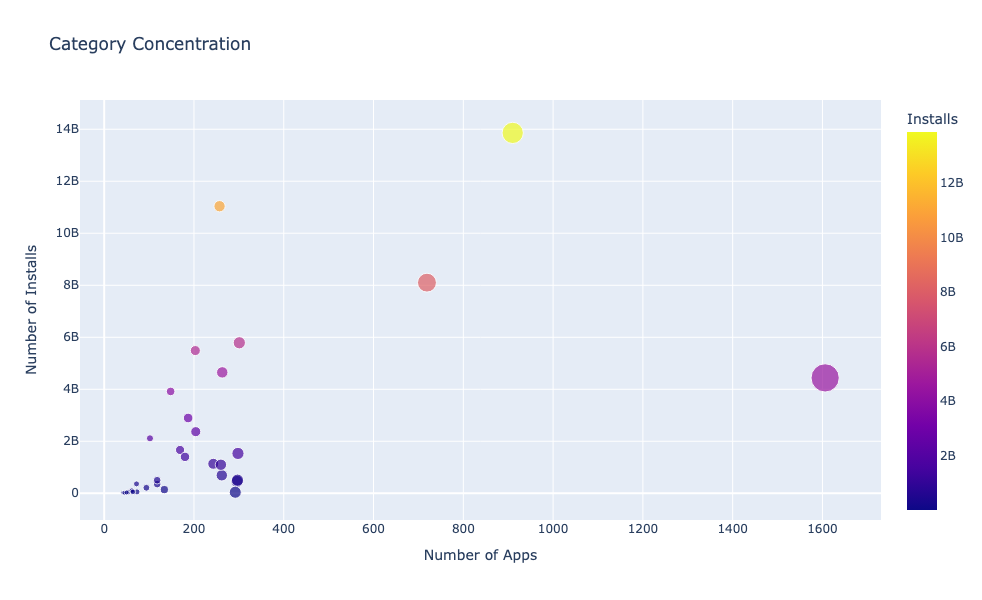

In [244]:
scatter_plot = px.scatter(cat_merged_df, 
                          x='App', 
                          y='Installs', 
                          title='Category Concentration', 
                          size='App', 
                          hover_name=cat_merged_df.index, 
                          color='Installs',
                          height=600) 
scatter_plot.update_layout(xaxis_title='Number of Apps',
                           yaxis_title='Number of Installs')
scatter_plot.show() 

# Extracting Nested Data from a Column

**Challenge**: How many different types of genres are there? Can an app belong to more than one genre? Check what happens when you use .value_counts() on a column with nested values? See if you can work around this problem by using the .split() function and the DataFrame's [.stack() method](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.stack.html). 


In [255]:
# To find number of Genres 
# Method 1 
print(df_clean_apps.Genres.value_counts().count())

# Method 2 
print(len(df_clean_apps.Genres.unique())) 

114
114


In [262]:
df_clean_apps.Genres.value_counts().sort_values(ascending=True).head() 

# isme hume ye dekhne ko mila ki ek hi app ke multiple genres bhi ho skte hai 

Genres
Lifestyle;Pretend Play      1
Strategy;Education          1
Adventure;Education         1
Role Playing;Brain Games    1
Tools;Education             1
Name: count, dtype: int64

In [266]:
# Splitting the columns on the basis of ; and then .stack them 

stack = df_clean_apps.Genres.str.split(';', expand=True).stack() 
print(f"Now we have a single column with shape: {stack.shape}")
num_genres = stack.value_counts() 
print(f"Number of Genres: {len(num_genres)}")

Now we have a single column with shape: (8564,)
Number of Genres: 53


In [270]:
num_genres.head() 

Tools            719
Education        587
Entertainment    498
Action           304
Productivity     301
Name: count, dtype: int64

# Colour Scales in Plotly Charts - Competition in Genres

**Challenge**: Can you create this chart with the Series containing the genre data? 

<img src=https://imgur.com/DbcoQli.png width=400>

Try experimenting with the built in colour scales in Plotly. You can find a full list [here](https://plotly.com/python/builtin-colorscales/). 

* Find a way to set the colour scale using the color_continuous_scale parameter. 
* Find a way to make the color axis disappear by using coloraxis_showscale. 

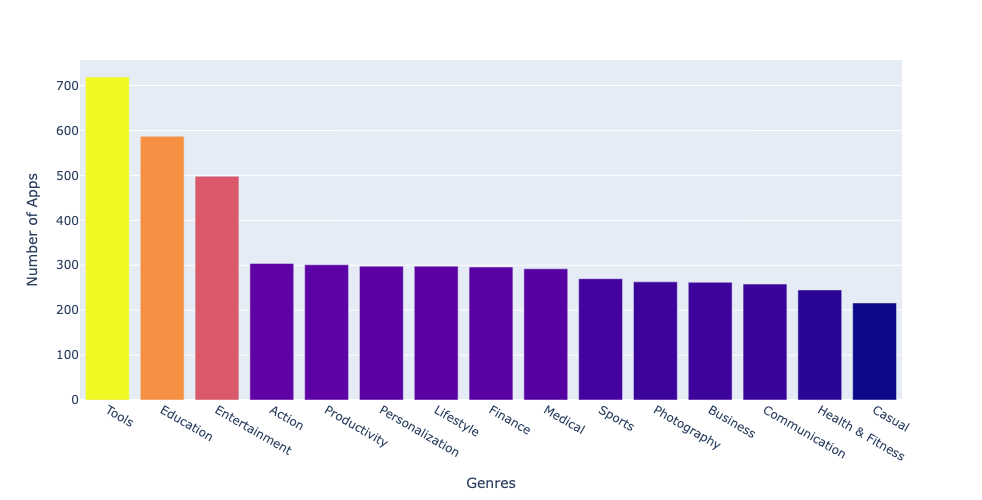

In [284]:
bar_chart = px.bar(x=num_genres.index[:15], 
                   y=num_genres.values[:15],
                   hover_name=num_genres.index[:15],
                   color=num_genres.values[:15],
                   height=500
                  ) 
bar_chart.update_layout(xaxis_title='Genres',
                        yaxis_title='Number of Apps',
                        coloraxis_showscale=False
                       )
bar_chart.show() 

# Grouped Bar Charts: Free vs. Paid Apps per Category

In [286]:
df_clean_apps.Type.value_counts() 

Type
Free    7595
Paid     589
Name: count, dtype: int64

In [288]:
df_free_vs_paid = df_clean_apps.groupby(['Category','Type'], as_index=False).agg({'App':pd.Series.count})

In [292]:
print(df_free_vs_paid.shape)
print(df_free_vs_paid.head()) 

(61, 3)
            Category  Type  App
0     ART_AND_DESIGN  Free   58
1     ART_AND_DESIGN  Paid    3
2  AUTO_AND_VEHICLES  Free   72
3  AUTO_AND_VEHICLES  Paid    1
4             BEAUTY  Free   42


**Challenge**: Use the plotly express bar [chart examples](https://plotly.com/python/bar-charts/#bar-chart-with-sorted-or-ordered-categories) and the [.bar() API reference](https://plotly.com/python-api-reference/generated/plotly.express.bar.html#plotly.express.bar) to create this bar chart: 

<img src=https://imgur.com/LE0XCxA.png>

You'll want to use the `df_free_vs_paid` DataFrame that you created above that has the total number of free and paid apps per category. 

See if you can figure out how to get the look above by changing the `categoryorder` to 'total descending' as outlined in the documentation here [here](https://plotly.com/python/categorical-axes/#automatically-sorting-categories-by-name-or-total-value). 

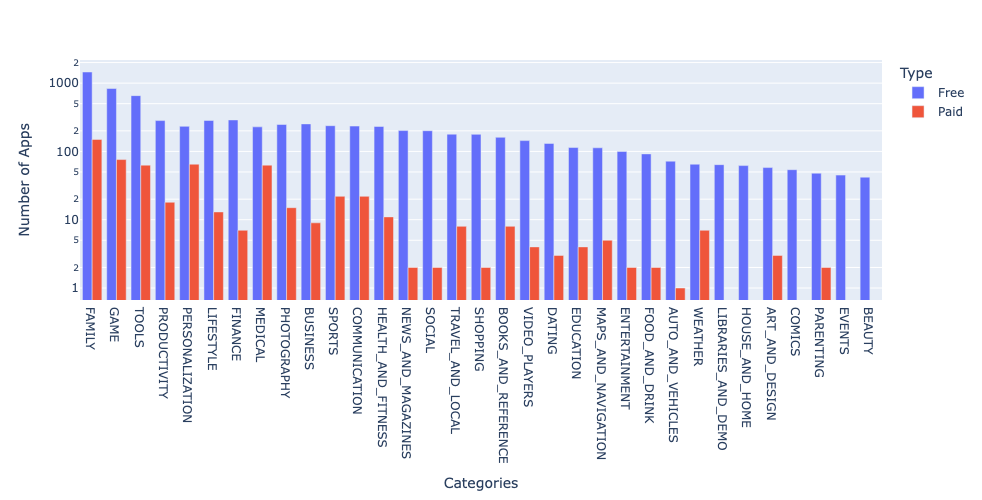

In [314]:
grouped_bar_chart = px.bar(df_free_vs_paid, 
                           x=df_free_vs_paid.Category, 
                           y=df_free_vs_paid.App, 
                           height=500, 
                           width=1000, 
                           color='Type', 
                           barmode='group'
                          )
grouped_bar_chart.update_layout(yaxis_title="Number of Apps",
                                xaxis_title="Categories",
                                xaxis={'categoryorder':'total descending'}, 
                                yaxis=dict(type='log')
                               )
grouped_bar_chart.show() 

# Plotly Box Plots: Lost Downloads for Paid Apps

**Challenge**: Create a box plot that shows the number of Installs for free versus paid apps. How does the median number of installations compare? Is the difference large or small?

Use the [Box Plots Guide](https://plotly.com/python/box-plots/) and the [.box API reference](https://plotly.com/python-api-reference/generated/plotly.express.box.html) to create the following chart. 

<img src=https://imgur.com/uVsECT3.png>


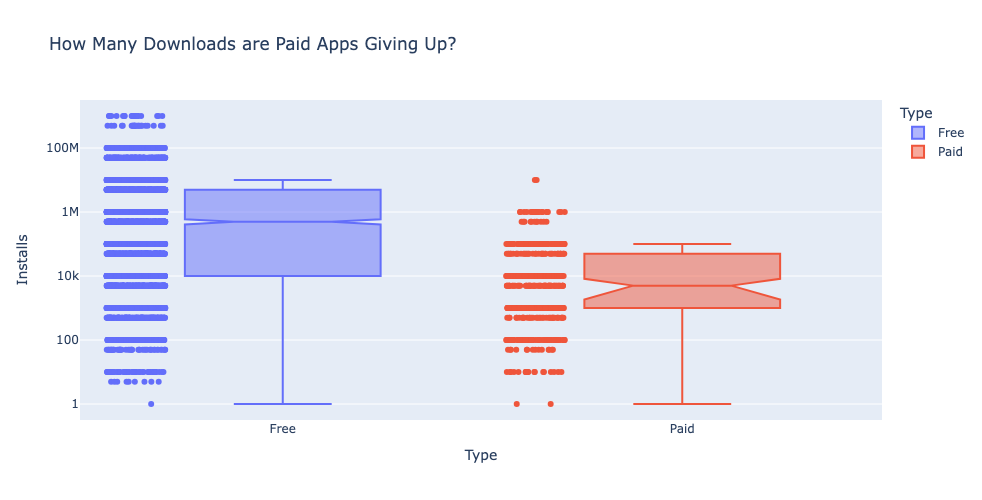

In [336]:
box_plot = px.box(df_clean_apps, 
                  x='Type', 
                  y='Installs', 
                  color='Type',
                  notched=True,
                  points='all', 
                  title="How Many Downloads are Paid Apps Giving Up?", 
                  height=500
                 )
box_plot.update_layout( yaxis=dict(type='log'))
box_plot.show() 

# Plotly Box Plots: Revenue by App Category

**Challenge**: See if you can generate the chart below: 

<img src=https://imgur.com/v4CiNqX.png>

Looking at the hover text, how much does the median app earn in the Tools category? If developing an Android app costs $30,000 or thereabouts, does the average photography app recoup its development costs?

Hint: I've used 'min ascending' to sort the categories. 

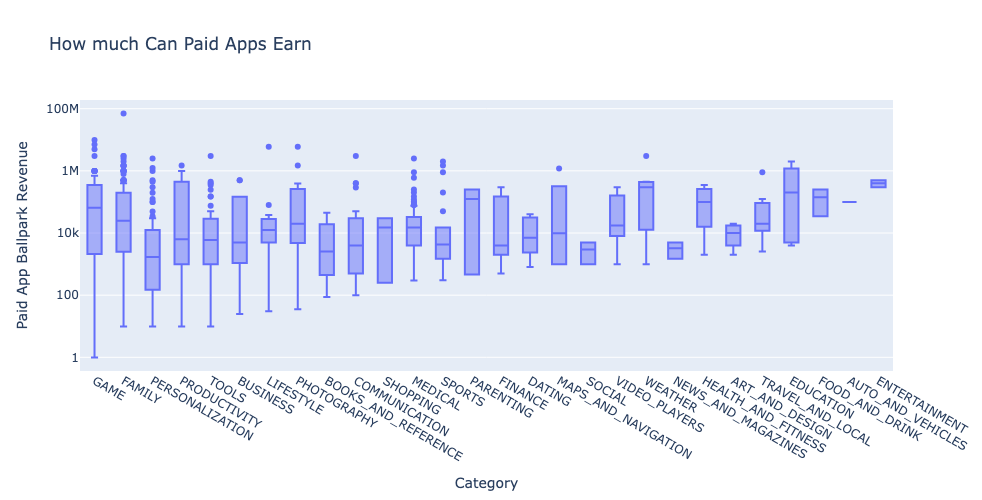

In [350]:
df_paid_apps = df_clean_apps[df_clean_apps['Type'] == 'Paid']
paid_box_plot = px.box(df_paid_apps, 
                       x='Category',
                       y='Revenue_Estimate',
                       title='How much Can Paid Apps Earn',
                       height=500
                      )
paid_box_plot.update_layout(xaxis_title='Category', 
                            yaxis_title='Paid App Ballpark Revenue',
                            xaxis={'categoryorder':'min ascending'}, 
                            yaxis=dict(type='log') 
                           )
paid_box_plot.show() 

# How Much Can You Charge? Examine Paid App Pricing Strategies by Category

**Challenge**: What is the median price price for a paid app? Then compare pricing by category by creating another box plot. But this time examine the prices (instead of the revenue estimates) of the paid apps. I recommend using `{categoryorder':'max descending'}` to sort the categories.

In [352]:
df_paid_apps.Price.median() 

2.99

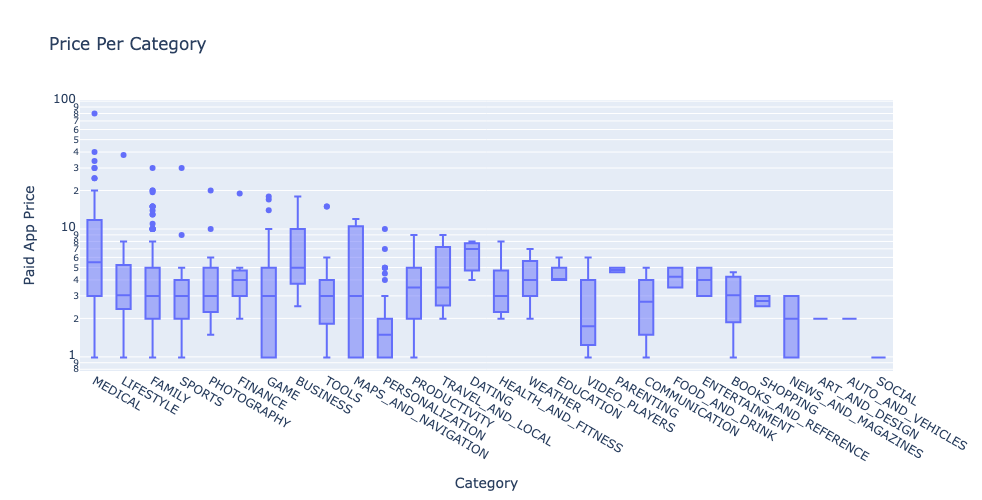

In [356]:
paid_box_plot = px.box(df_paid_apps, 
                       x='Category',
                       y='Price',
                       title='Price Per Category',
                       height=500
                      )
paid_box_plot.update_layout(xaxis_title='Category', 
                            yaxis_title='Paid App Price',
                            xaxis={'categoryorder':'max descending'}, 
                            yaxis=dict(type='log') 
                           )
paid_box_plot.show() 